# Diagnóstico de enfermedades en hojas de papa y café
### Notebook de entrenamiento — Papa (PlantVillage) y Café (RoCoLe)

Este notebook entrena y compara **3 experimentos** por cultivo:
1. CNN simple desde cero (baseline)
2. MobileNetV2 — transfer learning (feature extraction)
3. MobileNetV2 — transfer learning con fine-tuning

Al final se guardan los mejores modelos y el mapeo de clases, listos para usar en la app Flask.

**Antes de correr:** sube tus datasets ya limpios a Google Drive con esta estructura:
```
MiDrive/proyecto_ia/data/potato/{Potato___Early_blight, Potato___Late_blight, Potato___healthy}
MiDrive/proyecto_ia/data/coffee/{coffee___healthy, coffee___rust, coffee___red_spider_mite}
```

Enlaces de donde se obtuvo los datasets:

Hojas de Papa(PlantVillage (subset "color", solo carpetas de papa) — Kaggle):
https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset

Carpetas:
Potato___Early_blight, Potato___Late_blight, Potato___healthy

Hojas de Cafe(RoCoLe (Robusta Coffee Leaf Images) — Kaggle / Mendeley Data):
https://www.kaggle.com/code/nirmalsankalana/plant-disease-classification-train-dataset

Carpetas:
coffee___healthy, coffee___red_spider_mite, coffee___rust


## 1. Configuración inicial y montaje de Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

print("TensorFlow version:", tf.__version__)

Mounted at /content/drive
TensorFlow version: 2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
BASE_DIR = '/content/drive/MyDrive/proyecto_ia'
MODELS_DIR = f'{BASE_DIR}/models'
os.makedirs(MODELS_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

CULTIVOS = {
    'papa': f'{BASE_DIR}/data/potato',
    'cafe': f'{BASE_DIR}/data/coffee',
}

## 2. Verificación rápida de datos (EDA mínimo)

Antes de entrenar, confirma cuántas imágenes hay por clase en cada cultivo.

In [4]:
for cultivo, ruta in CULTIVOS.items():
    print(f"\n=== {cultivo.upper()} ===")
    for clase in sorted(os.listdir(ruta)):
        n = len(os.listdir(os.path.join(ruta, clase)))
        print(f"  {clase}: {n} imágenes")


=== PAPA ===
  Potato___Early_blight: 1000 imágenes
  Potato___Late_blight: 1000 imágenes
  Potato___healthy: 152 imágenes

=== CAFE ===
  coffee___healthy: 759 imágenes
  coffee___red_spider_mite: 167 imágenes
  coffee___rust: 579 imágenes


In [ ]:
# Visualiza algunos ejemplos por clase (EDA)
def mostrar_ejemplos(ruta_cultivo, n_por_clase=3):
    clases = sorted(os.listdir(ruta_cultivo))
    fig, axes = plt.subplots(len(clases), n_por_clase, figsize=(3*n_por_clase, 3*len(clases)))
    for i, clase in enumerate(clases):
        ruta_clase = os.path.join(ruta_cultivo, clase)
        archivos = os.listdir(ruta_clase)[:n_por_clase]
        for j, archivo in enumerate(archivos):
            img = tf.keras.utils.load_img(os.path.join(ruta_clase, archivo), target_size=IMG_SIZE)
            ax = axes[i, j] if len(clases) > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(clase, fontsize=9)
            ax.axis('off')
    plt.tight_layout()
    plt.show()

mostrar_ejemplos(CULTIVOS['papa'])
mostrar_ejemplos(CULTIVOS['cafe'])

Output hidden; open in https://colab.research.google.com to view.

## 3. Funciones reutilizables (carga de datos, augmentation, modelos)

In [5]:
def cargar_datasets(data_dir):
    """Carga train/val desde carpetas, retorna también los nombres de clase."""
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.2, subset="training",
        seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.2, subset="validation",
        seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
    )
    class_names = train_ds.class_names

    # Dividimos val_ds en validation real + test (mitad y mitad)
    val_batches = tf.data.experimental.cardinality(val_ds)
    test_ds = val_ds.take(val_batches // 2)
    val_ds = val_ds.skip(val_batches // 2)

    # Prefetch para rendimiento
    train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

In [7]:
def construir_cnn_desde_cero(num_clases):
    """Experimento 1: CNN simple entrenada desde cero (baseline)."""
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(32, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_clases, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name="cnn_desde_cero")
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [8]:
def construir_mobilenet(num_clases, fine_tune=False, capas_a_descongelar=20):
    """Experimentos 2 y 3: MobileNetV2 con transfer learning.
    fine_tune=False -> solo feature extraction (base congelada)
    fine_tune=True  -> descongela las últimas capas para ajuste fino
    """
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet'
    )
    base_model.trainable = fine_tune
    if fine_tune:
        for capa in base_model.layers[:-capas_a_descongelar]:
            capa.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_clases, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name=f"mobilenet_{'finetune' if fine_tune else 'feat_extract'}")

    lr = 1e-5 if fine_tune else 1e-3
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model, base_model

In [9]:
def calcular_class_weights(train_ds):
    """Calcula pesos de clase para compensar desbalance."""
    labels = np.concatenate([y for x, y in train_ds], axis=0)
    clases_unicas = np.unique(labels)
    pesos = compute_class_weight('balanced', classes=clases_unicas, y=labels)
    return dict(zip(clases_unicas, pesos))

In [10]:
def entrenar_modelo(model, train_ds, val_ds, nombre_run, class_weight=None,
                     epochs=20, patience=4):
    checkpoint_path = f'{MODELS_DIR}/checkpoint_{nombre_run}.keras'
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path, save_best_only=True, monitor='val_accuracy'
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=patience, restore_best_weights=True
        ),
    ]
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=epochs,
        callbacks=callbacks, class_weight=class_weight
    )
    return history

In [11]:
def evaluar_modelo(model, test_ds, class_names, nombre_run):
    y_true, y_pred = [], []
    for x, y in test_ds:
        preds = model.predict(x, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(y.numpy())

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    acc = np.mean(y_true == y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n=== {nombre_run} ===")
    print(f"Accuracy: {acc:.4f} | F1-macro: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de confusión - {nombre_run}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.show()

    return {'nombre': nombre_run, 'accuracy': acc, 'f1_macro': f1}

In [12]:
def graficar_historia(history, nombre_run):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title(f'Accuracy - {nombre_run}')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title(f'Loss - {nombre_run}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 4. Entrenamiento — Papa

Corremos los 3 experimentos para el cultivo de papa.

In [ ]:
train_papa, val_papa, test_papa, clases_papa = cargar_datasets(CULTIVOS['papa'])
print("Clases papa:", clases_papa)

class_weight_papa = calcular_class_weights(train_papa)
print("Class weights:", class_weight_papa)

Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Clases papa: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Class weights: {np.int32(0): np.float64(0.7211055276381909), np.int32(1): np.float64(0.7148194271481942), np.int32(2): np.float64(4.666666666666667)}


Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.4553 - loss: 1.2274 - val_accuracy: 0.2087 - val_loss: 1.3842
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 215s 4s/step - accuracy: 0.6829 - loss: 0.6131 - val_accuracy: 0.6408 - val_loss: 0.7272
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 226s 4s/step - accuracy: 0.8345 - loss: 0.3588 - val_accuracy: 0.9078 - val_loss: 0.2656
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.8821 - loss: 0.2649 - val_accuracy: 0.9223 - val_loss: 0.2073
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 289s 4s/step - accuracy: 0.8757 - loss: 0.3141 - val_accuracy: 0.8495 - val_loss: 0.3220
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 273s 5s/step - accuracy: 0.8734 - loss: 0.3308 - val_accuracy: 0.8155 - val_loss: 0.4343
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 209s 4s/step - accuracy: 0.9146 - loss: 0.1874 - val_accuracy: 0.9272 - val_loss: 0.1733
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.9262 - loss: 0.1808 - val_accuracy: 0.7913 - v

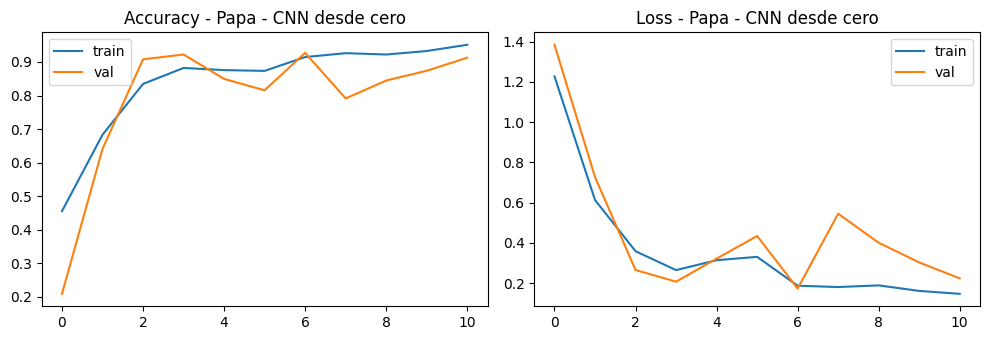

In [ ]:
# Experimento 1: CNN desde cero
cnn_papa = construir_cnn_desde_cero(len(clases_papa))
hist_cnn_papa = entrenar_modelo(cnn_papa, train_papa, val_papa,
                                 'papa_cnn_scratch', class_weight=class_weight_papa)
graficar_historia(hist_cnn_papa, 'Papa - CNN desde cero')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7056 - loss: 0.6552 - val_accuracy: 0.9272 - val_loss: 0.2678
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.9007 - loss: 0.2584 - val_accuracy: 0.9369 - val_loss: 0.2566
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9321 - loss: 0.1871 - val_accuracy: 0.9612 - val_loss: 0.1521
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9576 - loss: 0.1369 - val_accuracy: 0.9078 - val_loss: 0.2336
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9460 - loss: 0.1274 - val_accuracy: 0.9417 - val_loss: 0.1411
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9530 - loss: 0.1209 - val_accuracy: 0.9612 - val_loss: 0.1281
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9599 - loss: 0.1125 - val_accuracy: 0.9417 - val_loss: 0.1579


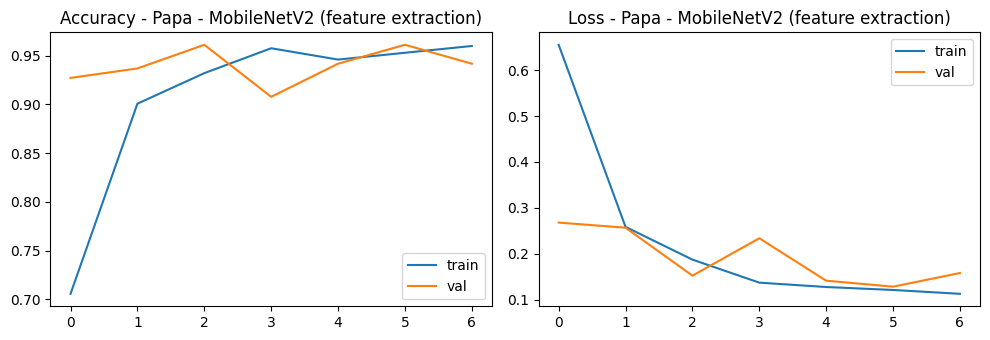

In [ ]:
# Experimento 2: MobileNetV2 - feature extraction
mnet_papa, base_papa = construir_mobilenet(len(clases_papa), fine_tune=False)
hist_mnet_papa = entrenar_modelo(mnet_papa, train_papa, val_papa,
                                  'papa_mobilenet_feat', class_weight=class_weight_papa)
graficar_historia(hist_mnet_papa, 'Papa - MobileNetV2 (feature extraction)')

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9013 - loss: 0.3412 - val_accuracy: 0.9078 - val_loss: 0.2368
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9326 - loss: 0.1789 - val_accuracy: 0.9029 - val_loss: 0.2738
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9460 - loss: 0.1660 - val_accuracy: 0.8786 - val_loss: 0.3110
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9530 - loss: 0.1352 - val_accuracy: 0.8981 - val_loss: 0.2888
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9553 - loss: 0.1150 - val_accuracy: 0.9126 - val_loss: 0.2497
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9559 - loss: 0.1068 - val_accuracy: 0.8641 - val_loss: 0.3172
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9582 - loss: 0.0916 - val_accuracy: 0.9369 - val_loss: 0.1502
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9623 - loss: 0.1122 - val_accuracy: 0.8835 - v

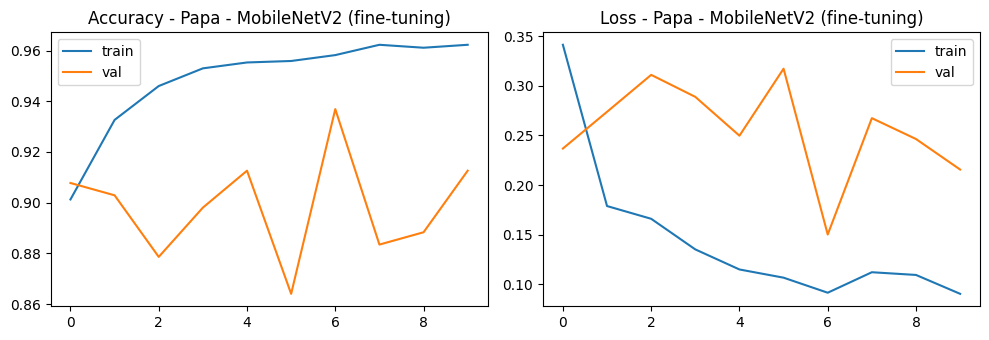

In [ ]:
# Experimento 3: MobileNetV2 - fine-tuning
# Partimos del modelo del experimento 2 y descongelamos las últimas capas
base_papa.trainable = True
for capa in base_papa.layers[:-20]:
    capa.trainable = False

mnet_papa.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_finetune_papa = entrenar_modelo(mnet_papa, train_papa, val_papa,
                                      'papa_mobilenet_finetune',
                                      class_weight=class_weight_papa, epochs=10)
graficar_historia(hist_finetune_papa, 'Papa - MobileNetV2 (fine-tuning)')


=== Papa - CNN desde cero ===
Accuracy: 0.9554 | F1-macro: 0.9382
                       precision    recall  f1-score   support

Potato___Early_blight       0.98      0.97      0.97       100
 Potato___Late_blight       0.97      0.93      0.95       104
     Potato___healthy       0.80      1.00      0.89        20

             accuracy                           0.96       224
            macro avg       0.92      0.97      0.94       224
         weighted avg       0.96      0.96      0.96       224



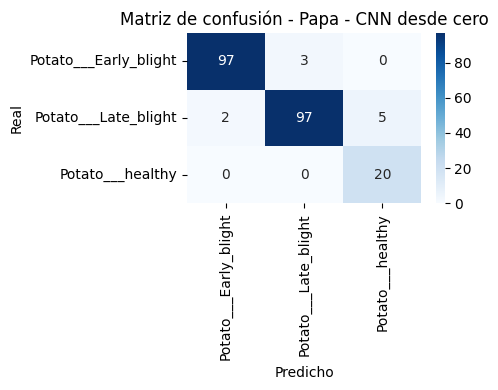


=== Papa - MobileNetV2 fine-tuned ===
Accuracy: 0.8929 | F1-macro: 0.8084
                       precision    recall  f1-score   support

Potato___Early_blight       0.99      0.94      0.96       102
 Potato___Late_blight       0.95      0.84      0.89       110
     Potato___healthy       0.40      1.00      0.57        12

             accuracy                           0.89       224
            macro avg       0.78      0.93      0.81       224
         weighted avg       0.94      0.89      0.91       224



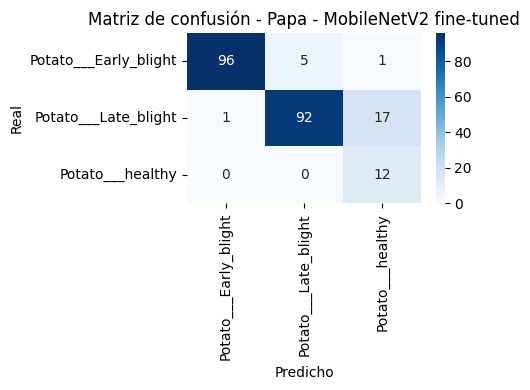

                          nombre  accuracy  f1_macro
0          Papa - CNN desde cero  0.955357  0.938248
1  Papa - MobileNetV2 fine-tuned  0.892857  0.808381


In [ ]:
# Evaluación comparativa de los 3 experimentos - Papa
resultados_papa = []
resultados_papa.append(evaluar_modelo(cnn_papa, test_papa, clases_papa, 'Papa - CNN desde cero'))
resultados_papa.append(evaluar_modelo(mnet_papa, test_papa, clases_papa, 'Papa - MobileNetV2 fine-tuned'))

import pandas as pd
df_papa = pd.DataFrame(resultados_papa)
print(df_papa)

In [ ]:
# Guardar modelo(s) de papa ya entrenados
mnet_papa.save(f'{MODELS_DIR}/modelo_papa.keras')
with open(f'{MODELS_DIR}/clases_papa.json', 'w') as f:
    json.dump(clases_papa, f)

# Guardar también la tabla de resultados de papa
df_papa.to_csv(f'{MODELS_DIR}/resultados_papa.csv', index=False)

In [ ]:
modelo_verificacion = tf.keras.models.load_model(f'{MODELS_DIR}/modelo_papa.keras')
print(modelo_verificacion.summary())

Model: "mobilenet_feat_extract"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,681,675 (17.86 MB)

 Trainable params: 1,209,923 (4.62 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2,419,848 (9.23 MB)

None


## 5. Entrenamiento — Café

Repetimos exactamente el mismo proceso para café.

In [13]:
train_cafe, val_cafe, test_cafe, clases_cafe = cargar_datasets(CULTIVOS['cafe'])
print("Clases café:", clases_cafe)

class_weight_cafe = calcular_class_weights(train_cafe)
print("Class weights:", class_weight_cafe)

Found 1505 files belonging to 3 classes.
Using 1204 files for training.
Found 1505 files belonging to 3 classes.
Using 301 files for validation.
Clases café: ['coffee___healthy', 'coffee___red_spider_mite', 'coffee___rust']
Class weights: {np.int32(0): np.float64(0.6633608815426997), np.int32(1): np.float64(2.9728395061728397), np.int32(2): np.float64(0.8649425287356322)}


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 240s 6s/step - accuracy: 0.3588 - loss: 1.1995 - val_accuracy: 0.0922 - val_loss: 1.1149
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.2907 - loss: 1.1015 - val_accuracy: 0.5035 - val_loss: 1.0296
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 177s 5s/step - accuracy: 0.3256 - loss: 1.0973 - val_accuracy: 0.4894 - val_loss: 1.0776
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 184s 5s/step - accuracy: 0.3862 - loss: 1.0796 - val_accuracy: 0.5035 - val_loss: 1.0170
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 173s 5s/step - accuracy: 0.3904 - loss: 1.0743 - val_accuracy: 0.2199 - val_loss: 1.1124
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 174s 5s/step - accuracy: 0.4360 - loss: 1.0652 - val_accuracy: 0.4610 - val_loss: 1.0792


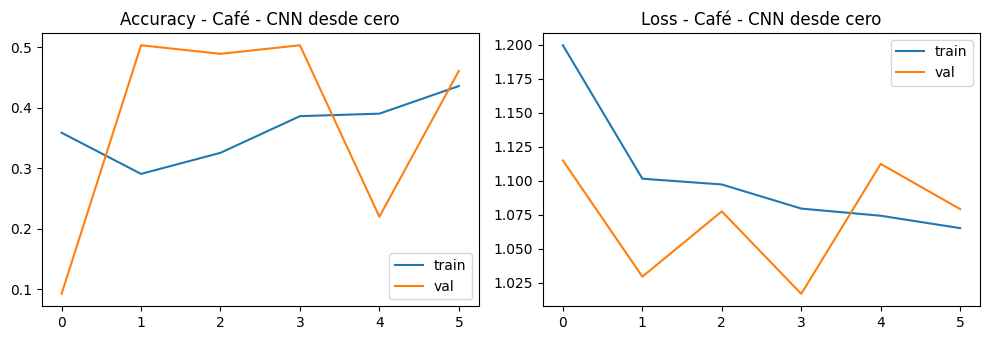

In [14]:
# Experimento 1: CNN desde cero
cnn_cafe = construir_cnn_desde_cero(len(clases_cafe))
hist_cnn_cafe = entrenar_modelo(cnn_cafe, train_cafe, val_cafe,
                                 'cafe_cnn_scratch', class_weight=class_weight_cafe)
graficar_historia(hist_cnn_cafe, 'Café - CNN desde cero')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.4252 - loss: 1.2112 - val_accuracy: 0.4113 - val_loss: 1.0913
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.5424 - loss: 1.0066 - val_accuracy: 0.4468 - val_loss: 1.0652
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.5997 - loss: 0.9235 - val_accuracy: 0.4468 - val_loss: 1.0858
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.6047 - loss: 0.8842 - val_accuracy: 0.5319 - val_loss: 1.0261
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6246 - loss: 0.8737 - val_accuracy: 0.5319 - val_loss: 0.9418
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6387 - loss: 0.8463 - val_accuracy: 0.4681 - val_loss: 1.0541
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6528 - loss: 0.8400 - val_accuracy: 0.6170 - val_loss: 0.7773
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.68

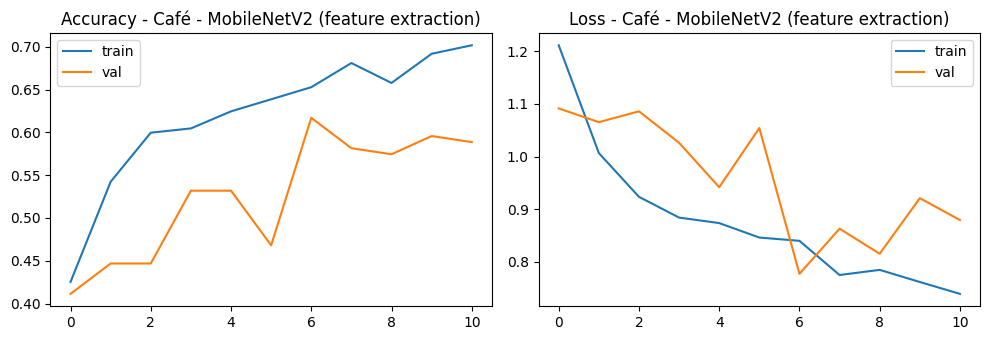

In [15]:
# Experimento 2: MobileNetV2 - feature extraction
mnet_cafe, base_cafe = construir_mobilenet(len(clases_cafe), fine_tune=False)
hist_mnet_cafe = entrenar_modelo(mnet_cafe, train_cafe, val_cafe,
                                  'cafe_mobilenet_feat', class_weight=class_weight_cafe)
graficar_historia(hist_mnet_cafe, 'Café - MobileNetV2 (feature extraction)')

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.4045 - loss: 1.1195 - val_accuracy: 0.5603 - val_loss: 0.8944
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.5008 - loss: 0.9496 - val_accuracy: 0.6099 - val_loss: 0.7786
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.5839 - loss: 0.8633 - val_accuracy: 0.6099 - val_loss: 0.8701
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.6437 - loss: 0.7992 - val_accuracy: 0.6809 - val_loss: 0.7760
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.6678 - loss: 0.7782 - val_accuracy: 0.5745 - val_loss: 0.8457
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.6786 - loss: 0.7517 - val_accuracy: 0.6525 - val_loss: 0.7506
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.6761 - loss: 0.7765 - val_accuracy: 0.7021 - val_loss: 0.6778
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.6852 - loss: 0.7454 - val_accuracy: 0.7021 - v

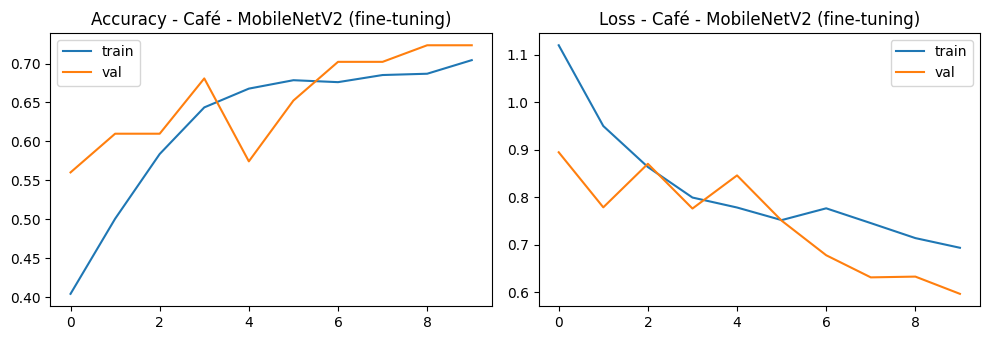

In [16]:
# Experimento 3: MobileNetV2 - fine-tuning
base_cafe.trainable = True
for capa in base_cafe.layers[:-20]:
    capa.trainable = False

mnet_cafe.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_finetune_cafe = entrenar_modelo(mnet_cafe, train_cafe, val_cafe,
                                      'cafe_mobilenet_finetune',
                                      class_weight=class_weight_cafe, epochs=10)
graficar_historia(hist_finetune_cafe, 'Café - MobileNetV2 (fine-tuning)')


=== Café - CNN desde cero ===
Accuracy: 0.4437 | F1-macro: 0.2509
                          precision    recall  f1-score   support

        coffee___healthy       0.46      0.85      0.60        75
coffee___red_spider_mite       0.00      0.00      0.00        16
           coffee___rust       0.35      0.10      0.16        69

                accuracy                           0.44       160
               macro avg       0.27      0.32      0.25       160
            weighted avg       0.37      0.44      0.35       160



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


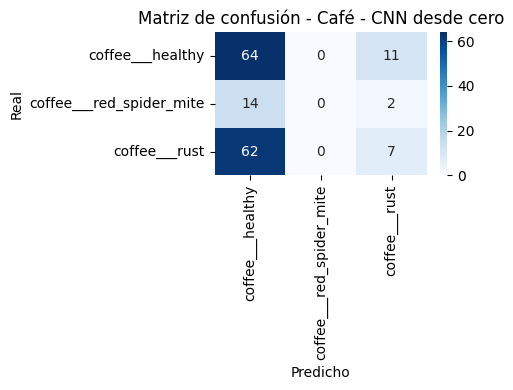


=== Café - MobileNetV2 fine-tuned ===
Accuracy: 0.7000 | F1-macro: 0.5877
                          precision    recall  f1-score   support

        coffee___healthy       0.82      0.82      0.82        85
coffee___red_spider_mite       0.29      0.33      0.31        15
           coffee___rust       0.64      0.62      0.63        60

                accuracy                           0.70       160
               macro avg       0.59      0.59      0.59       160
            weighted avg       0.70      0.70      0.70       160



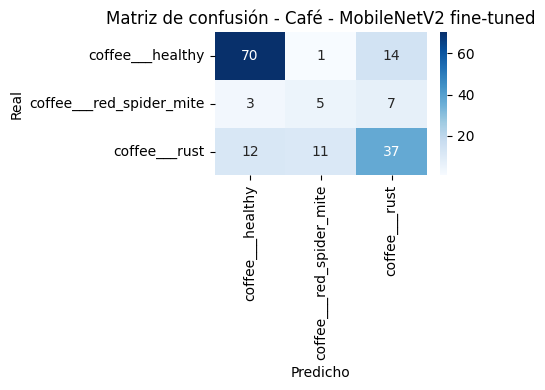

                          nombre  accuracy  f1_macro
0          Café - CNN desde cero   0.44375  0.250884
1  Café - MobileNetV2 fine-tuned   0.70000  0.587716


In [18]:
# Evaluación comparativa de los 3 experimentos - Café
resultados_cafe = []
resultados_cafe.append(evaluar_modelo(cnn_cafe, test_cafe, clases_cafe, 'Café - CNN desde cero'))
resultados_cafe.append(evaluar_modelo(mnet_cafe, test_cafe, clases_cafe, 'Café - MobileNetV2 fine-tuned'))
import pandas as pd
df_cafe = pd.DataFrame(resultados_cafe)
print(df_cafe)

## 6. Guardar modelos finales y mapeo de clases

Guarda el mejor modelo por cultivo (normalmente el de fine-tuning) junto con
el orden de clases.

In [20]:
# Guardar modelo final de PAPA (ajusta si otro experimento dio mejor resultado)
#mnet_papa.save(f'{MODELS_DIR}/modelo_papa.keras')
#with open(f'{MODELS_DIR}/clases_papa.json', 'w') as f:
#    json.dump(clases_papa, f)

# Guardar modelo final de CAFÉ
mnet_cafe.save(f'{MODELS_DIR}/modelo_cafe.keras')
with open(f'{MODELS_DIR}/clases_cafe.json', 'w') as f:
    json.dump(clases_cafe, f)

print("Modelos y mapeos de clases guardados en:", MODELS_DIR)

Modelos y mapeos de clases guardados en: /content/drive/MyDrive/proyecto_ia/models


## 7. Tabla comparativa final (para el README)

Combina los resultados de ambos cultivos en una sola tabla. 

In [25]:
df_papa = pd.read_csv(f'{MODELS_DIR}/resultados_papa.csv')
df_papa['cultivo'] = 'papa'
df_cafe['cultivo'] = 'cafe'
df_final = pd.concat([df_papa, df_cafe], ignore_index=True)
df_final = df_final[['cultivo', 'nombre', 'accuracy', 'f1_macro']]
print(df_final.to_string(index=False))
df_final.to_csv(f'{MODELS_DIR}/resultados_experimentos.csv', index=False)

cultivo                        nombre  accuracy  f1_macro
   papa         Papa - CNN desde cero  0.955357  0.938248
   papa Papa - MobileNetV2 fine-tuned  0.892857  0.808381
   cafe         Café - CNN desde cero  0.443750  0.250884
   cafe Café - MobileNetV2 fine-tuned  0.700000  0.587716


## 8. Descargar los archivos necesarios para el proyecto Flask

Ejecuta esta celda al final para descargar los 4 archivos para colocar en `backend/models/` de tu repositorio.

In [26]:
from google.colab import files

for archivo in ['modelo_papa.keras', 'clases_papa.json',
                'modelo_cafe.keras', 'clases_cafe.json']:
    files.download(f'{MODELS_DIR}/{archivo}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Notas importantes

- **Preprocesamiento en Flask:** recuerda usar `tf.keras.applications.mobilenet_v2.preprocess_input`
  al procesar la imagen antes de predecir — el modelo fue entrenado esperando ese preprocesamiento,
  no una simple división entre 255.
- **Versión de TensorFlow:** anota la versión usada aquí (`tf.__version__`) y usa la misma
  (o una compatible) en tu `requirements.txt` de Flask.